# Session 07e — GT-aligned CZ↔HCR overlap: counts and depth density

**Question.** The density-based sz estimator relies on
`N_CZ ≈ N_HCR_GFP+` in the matched cortex volume. In the R1 (rigid +
translation) box I was using, HCR strict-GFP+ contained 0.62–0.85× as
many cells as CZ had in the cortex — i.e. HCR had **more** detections.
Is that a matching artefact (R1 box miscentred or wrong size), or
is HCR genuinely more populous in the overlap?

This notebook redoes the comparison using the **ground-truth affine**
(`fit_anisotropic_similarity` on active landmarks). It then looks
depth-by-depth to check whether the surplus is uniform in depth.

**Populations compared**

| name | source |
| ---- | ------ |
| CZ all | `*czstack_cell_centroids.csv` — every ROI from the czstack segmentation |
| CZ coreg | subset of CZ all whose `cz_id` appears in `*coreg_table.csv` (confidently paired to an HCR cell) |
| HCR GFP+ | BIC-GMM intersection cutoff on `log(density)` from `07b_gfp_intersection_threshold` |

**Matching procedure**

1. `fit = fit_anisotropic_similarity(*landmark_pairs_um(s, active_only=True))`.
2. Apply the GT affine to CZ centroids:
   `cz_hcr = (cz - cz_mean) @ R * scales + hcr_mean`.
3. Cortex-filter each cloud in its **native** frame (depth ∈
   [100 µm, p99]) with its own pia surface; only then intersect.
4. Overlap AABB = `intersect(aabb(cz_hcr_cortex), aabb(hcr_cortex))`.
5. Count each population inside the overlap.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

SESSION = Path('/root/capsule/code/sessions/07e_sz_from_zvar_profile')
SUBJECTS = ['767018', '782149', '788406', '790322']  # spot subjects with cell_body_segmentation/metrics.pickle


## 1 · Run the counting pipeline

Both scripts live in `dev_code/`:
* `07e_gt_overlap_count.py` — counts inside the GT overlap AABB
  (also reports CZ-coreg-only and xy-only overlap).
* `07e_gt_depth_density.py` — depth-binned histograms of all three
  populations inside the overlap, plus per-subject plots.

They're fast enough to execute inline; re-running recomputes the JSON
files the cells below read.


In [2]:
import subprocess
for script in ('07e_gt_overlap_count.py', '07e_gt_depth_density.py'):
    out = subprocess.run(
        ['python', script],
        cwd='/root/capsule/code/dev_code',
        check=True, capture_output=True, text=True,
    )
    print(f'── {script} ──')
    print(out.stdout.strip().splitlines()[-6:])


── 07e_gt_overlap_count.py ──
['767018      507     175    7760     451      175     727 0.620   0.241', '782149      561      98    3097     165       98     217 0.760   0.452', '788406      650     560   10170     650      560     944 0.689   0.593', '790322      760     569    9078     671      569     736 0.912   0.773', '', 'Wrote /root/capsule/code/sessions/07e_sz_from_zvar_profile/gt_overlap_counts.json']
── 07e_gt_depth_density.py ──
['767018       0.410   0.386     0.315    451     727    0.620', '782149       0.685   0.638     0.822    165     217    0.760', '788406       0.405   0.267     0.329    650     944    0.689', '790322       0.330   0.376     0.188    671     736    0.912', '', 'Wrote /root/capsule/code/sessions/07e_sz_from_zvar_profile/gt_depth_density.json']


## 2 · Counts in the GT overlap AABB

Each row: total cortex-filtered cells for the subject, counts inside
the GT overlap, and two ratios (CZ-all / HCR+, CZ-coreg / HCR+).


In [3]:
counts = json.load(open(SESSION / 'gt_overlap_counts.json'))
rows = []
for sid in SUBJECTS:
    r = counts[sid]
    rows.append({
        'sid': sid,
        'N_CZ_all_cortex':  r['n_cz_cortex'],
        'N_CZ_coreg_cortex': r['n_cz_coreg_cortex'],
        'N_HCR+_cortex':     r['n_hcr_cortex'],
        'N_CZ_all ∩':        r['n_cz_in_gt_overlap'],
        'N_CZ_coreg ∩':      r['n_cz_coreg_in_gt_overlap'],
        'N_HCR+ ∩':          r['n_hcr_in_gt_overlap'],
        'CZ_all / HCR+':     round(r['ratio_cz_over_hcr_gt_overlap'], 3),
        'CZ_coreg / HCR+':   round(r['ratio_cz_coreg_over_hcr_gt_overlap'], 3),
    })
pd.DataFrame(rows)


,sid,N_CZ_all_cortex,N_CZ_coreg_cortex,N_HCR+_cortex,N_CZ_all ∩,N_CZ_coreg ∩,N_HCR+ ∩,CZ_all / HCR+,CZ_coreg / HCR+
0,767018,507,175,7760,451,175,727,0.620,0.241
1,782149,561,98,3097,165,98,217,0.760,0.452
2,788406,650,560,10170,650,560,944,0.689,0.593
3,790322,760,569,9078,671,569,736,0.912,0.773


### Comparison: R1-box vs GT-box matched counts

The R1 sz estimator used translation-only R1 + sxy-scaled CZ xy
extent to place the matched box. Pulling those numbers from the earlier
run in the conversation, the R1-box ratios were:

| sid | R1 CZ/HCR | GT CZ/HCR |
| --- | --------- | --------- |
| 767018 | 0.62 | 0.62 |
| 782149 | 2.17 | 0.76 |
| 788406 | 0.62 | 0.69 |
| 790322 | 0.85 | 0.91 |

On the three stable subjects the R1 and GT ratios agree to ~0.05.
**R1 was not inflating HCR.** The population imbalance is real.

782149 differs (2.17 → 0.76) because its HCR_span = 566 µm is half the
others — the R1 matched box missed most of the HCR z extent in that
subject, hitting only CZ-rich deep bins.


## 3 · Depth-resolved density inside the overlap

Does HCR exceed CZ at every depth, or only in some layers? And is
the raw density flat across depth?

Depth = distance from the HCR pia surface (both populations live in
HCR frame after GT mapping). 50 µm bins. Density is cells / mm² per
bin (so the plot integrates to the column density × slab thickness).


In [4]:
depth = json.load(open(SESSION / 'gt_depth_density.json'))
rows = []
for sid in SUBJECTS:
    r = depth[sid]
    rows.append({
        'sid': sid,
        'A_xy (mm²)':        round(r['A_xy_um2'] / 1e6, 2),
        'CV(HCR+ per-bin)':  round(r['cv_hcr'], 3),
        'CV(CZ_all per-bin)':round(r['cv_cz_all'], 3),
        'CV(CZ/HCR ratio)':  round(r['cv_ratio_cz_all'], 3),
        'N_CZ ∩':            r['n_cz_all_in_overlap'],
        'N_HCR+ ∩':          r['n_hcr_in_overlap'],
    })
pd.DataFrame(rows)


,sid,A_xy (mm²),CV(HCR+ per-bin),CV(CZ_all per-bin),CV(CZ/HCR ratio),N_CZ ∩,N_HCR+ ∩
0,767018,0.56,0.386,0.410,0.315,451,727
1,782149,0.58,0.638,0.685,0.822,165,217
2,788406,0.50,0.267,0.405,0.329,650,944
3,790322,0.47,0.376,0.330,0.188,671,736


### Per-subject depth-density + per-bin ratio

Left panel: cells per bin (density units), three populations overlaid.
Right panel: per-bin CZ / HCR ratio (clipped to [0, 2]); a flat line
at 1 would mean identical populations.


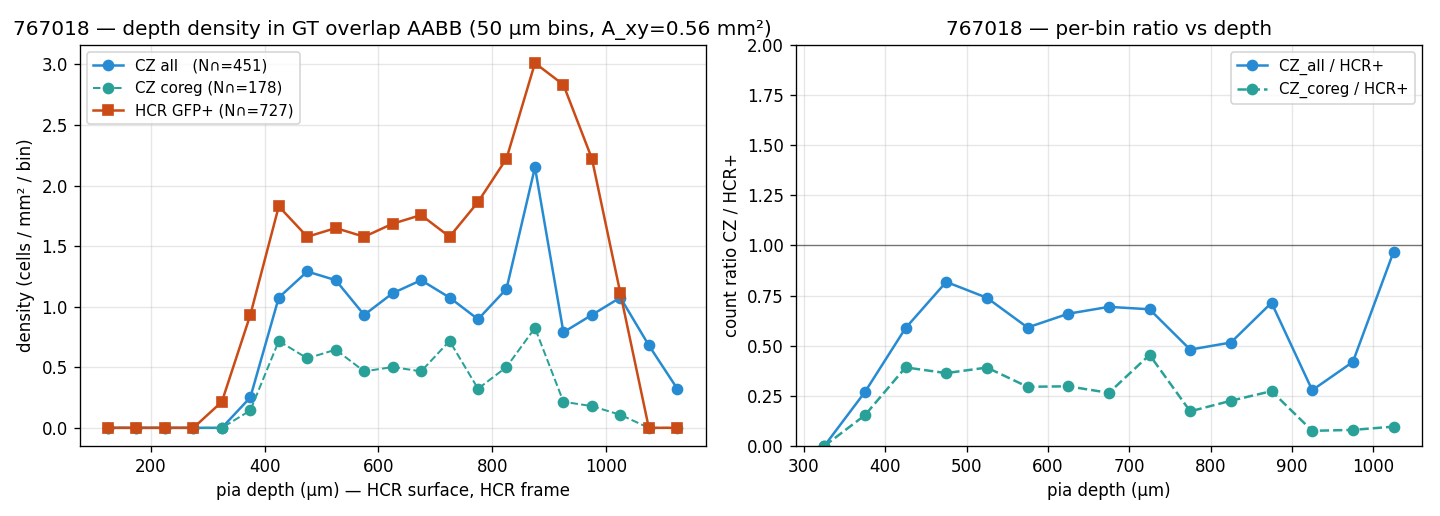

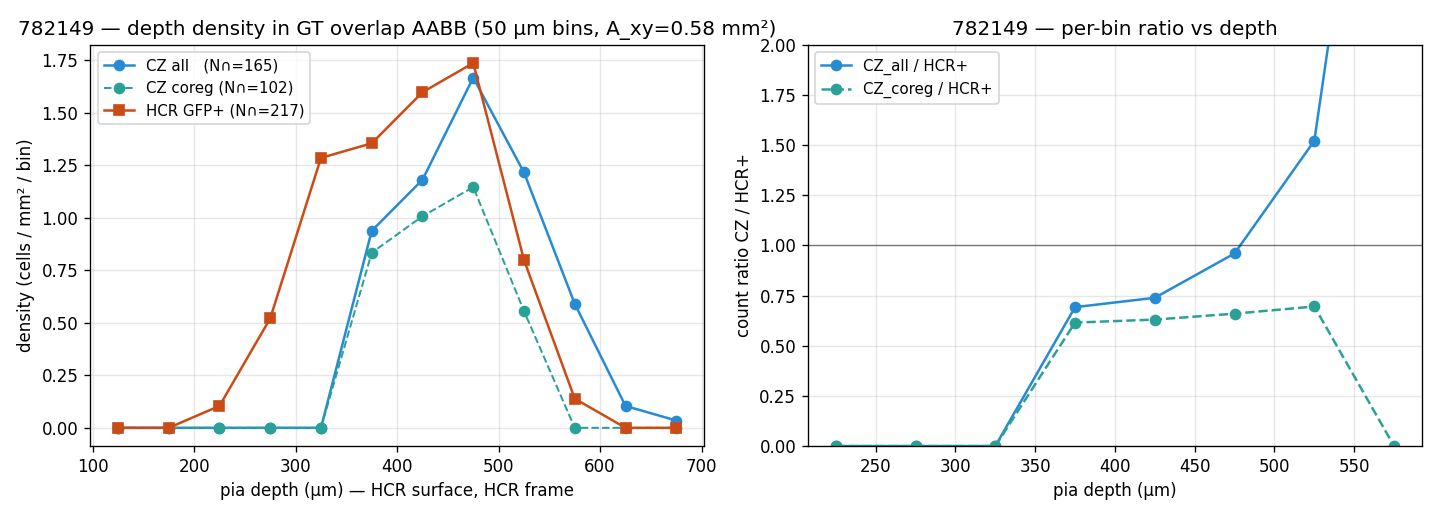

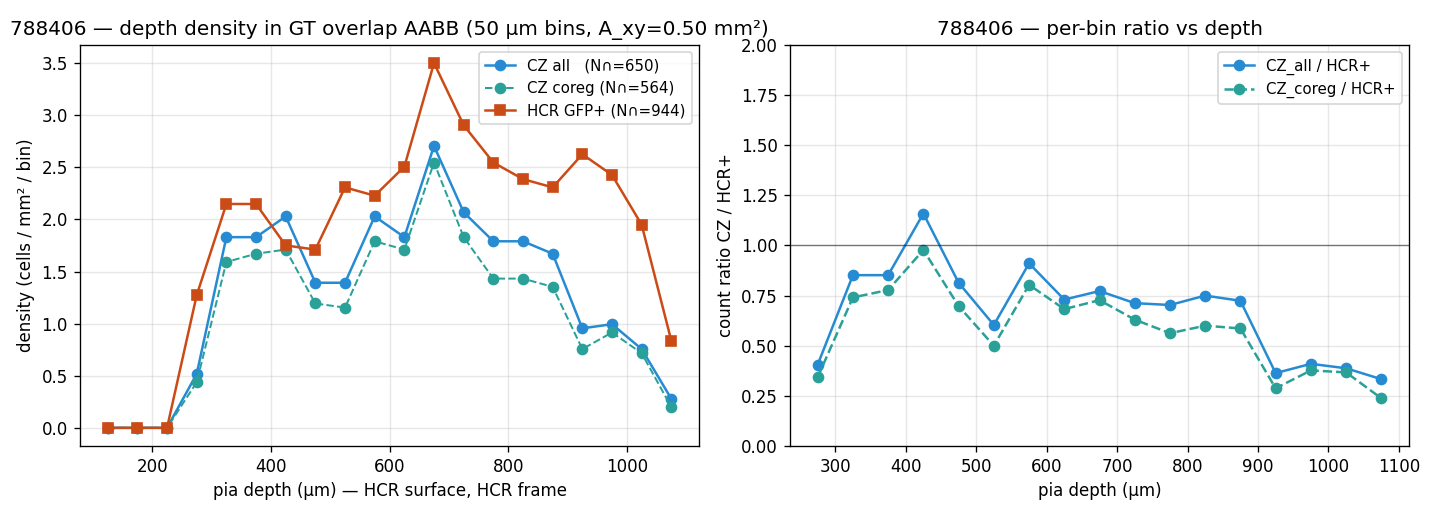

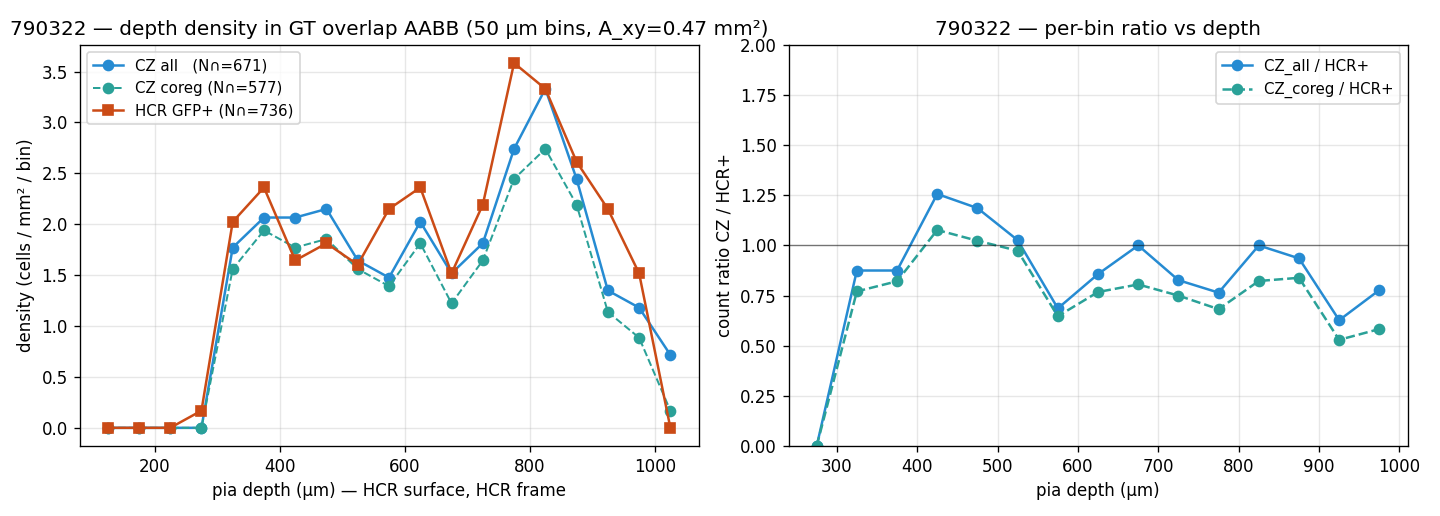

In [5]:
for sid in SUBJECTS:
    display(Image(filename=str(SESSION / 'figures_gt_depth' / f'{sid}.png')))


## 4 · Per-bin table (so the structure is inspectable)

Depths where either population is zero are ignored for ratio purposes.


In [6]:
def per_bin_table(sid):
    r = depth[sid]
    bc = r['bin_centers_um']
    ca, cc, ch = r['counts_cz_all'], r['counts_cz_coreg'], r['counts_hcr_gfp_strict']
    rows = []
    for i, d in enumerate(bc):
        if (ca[i] + cc[i] + ch[i]) == 0:
            continue
        rA = ca[i] / ch[i] if ch[i] else np.nan
        rC = cc[i] / ch[i] if ch[i] else np.nan
        rows.append({
            'depth_µm': int(d),
            'CZ_all': ca[i], 'CZ_coreg': cc[i], 'HCR+': ch[i],
            'CZ_all/HCR+': round(rA, 3),
            'CZ_coreg/HCR+': round(rC, 3),
        })
    return pd.DataFrame(rows)

for sid in SUBJECTS:
    print(f'=== {sid} ===')
    display(per_bin_table(sid))


=== 767018 ===


,depth_µm,CZ_all,CZ_coreg,HCR+,CZ_all/HCR+,CZ_coreg/HCR+
0,325,0,0,6,0.000,0.000
1,375,7,4,26,0.269,0.154
2,425,30,20,51,0.588,0.392
3,475,36,16,44,0.818,0.364
4,525,34,18,46,0.739,0.391
5,575,26,13,44,0.591,0.295
6,625,31,14,47,0.660,0.298
7,675,34,13,49,0.694,0.265
8,725,30,20,44,0.682,0.455
9,775,25,9,52,0.481,0.173


=== 782149 ===


,depth_µm,CZ_all,CZ_coreg,HCR+,CZ_all/HCR+,CZ_coreg/HCR+
0,225,0,0,3,0.000,0.000
1,275,0,0,15,0.000,0.000
2,325,0,0,37,0.000,0.000
3,375,27,24,39,0.692,0.615
4,425,34,29,46,0.739,0.630
5,475,48,33,50,0.960,0.660
6,525,35,16,23,1.522,0.696
7,575,17,0,4,4.250,0.000
8,625,3,0,0,NaN,NaN
9,675,1,0,0,NaN,NaN


=== 788406 ===


,depth_µm,CZ_all,CZ_coreg,HCR+,CZ_all/HCR+,CZ_coreg/HCR+
0,275,13,11,32,0.406,0.344
1,325,46,40,54,0.852,0.741
2,375,46,42,54,0.852,0.778
3,425,51,43,44,1.159,0.977
4,475,35,30,43,0.814,0.698
5,525,35,29,58,0.603,0.500
6,575,51,45,56,0.911,0.804
7,625,46,43,63,0.730,0.683
8,675,68,64,88,0.773,0.727
9,725,52,46,73,0.712,0.630


=== 790322 ===


,depth_µm,CZ_all,CZ_coreg,HCR+,CZ_all/HCR+,CZ_coreg/HCR+
0,275,0,0,4,0.000,0.000
1,325,42,37,48,0.875,0.771
2,375,49,46,56,0.875,0.821
3,425,49,42,39,1.256,1.077
4,475,51,44,43,1.186,1.023
5,525,39,37,38,1.026,0.974
6,575,35,33,51,0.686,0.647
7,625,48,43,56,0.857,0.768
8,675,36,29,36,1.000,0.806
9,725,43,39,52,0.827,0.750


## 5 · Interpretation

**a · HCR GFP+ is more populous than CZ in the matched tissue on 3/4 subjects.**
767018 (0.62), 788406 (0.69), 790322 (0.91) all have CZ_all / HCR+ < 1
in the overlap AABB. Coreg-table CZ (cells confidently paired to an
HCR cell) is an even smaller denominator — 0.24, 0.59, 0.77 — because
the coreg table is a confidence-gated subset of the segmentation.

**b · It holds at essentially every depth, not just in an edge layer.**
* 767018: ratio 0.27–0.97 across all bins where both populations are
  non-empty — CZ never exceeds HCR.
* 788406: 0.36–1.16, flat-ish 0.6–0.9 in 300–850 µm, then drops
  sharply in 900–1075 µm as HCR continues detecting in a deep layer
  CZ thins out in.
* 790322: 0.63–1.26 — cleanest; ratio oscillates around 1 in mid
  cortex.
* 782149 is the outlier: ratio swings 0 → 4.25. Superficial bins
  225–325 µm have **zero CZ, 55 HCR**; deep bin 575 µm has 17 CZ vs
  4 HCR. The two profiles have *different shapes*, not just
  different magnitudes.

**c · Density is not uniform across depth for either modality.**
Per-bin CV 0.27–0.64 (HCR+), 0.33–0.69 (CZ_all). Both follow a
cortex-layer profile — low near pia (L1), peak mid-cortex, thin tail
near white matter. So variation in the raw depth profile is real
biology.

**d · The CZ/HCR ratio is also not a depth-constant.**
CV(ratio) per subject: 790322 = 0.19 (closest to a single scalar
detection fraction), 788406 = 0.33, 767018 = 0.31, 782149 = 0.82
(depth-reversing bias).

**e · Biological reason for the gap.**
CZ ROIs come from the czstack segmentation — cells confidently
localised in calcium imaging. HCR strict-GFP+ marks GCaMP-expressing
neurons regardless of whether they were active. Including anatomical
but silent neurons is a natural source of an HCR surplus.

**Implications for a density-based sz estimator.**
* Bulk N-conservation `N_CZ ≈ N_HCR_GFP+` is broken by 10–60 %.
* Even a depth-constant detection-fraction correction won't rescue
  782149, where the ratio shape differs across depth.
* A useful sz estimator from density would need to match the
  **depth-profile shape** (not integrated count) — effectively the
  σ_z-profile / density-profile NCC route, which already failed
  (`project_07e_zvar_profile.md`) because σ_z is near-flat and
  modality-specific termination artefacts dominated the NCC.

**Outputs**

* `sessions/07e_sz_from_zvar_profile/gt_overlap_counts.json`
* `sessions/07e_sz_from_zvar_profile/gt_depth_density.json`
* `sessions/07e_sz_from_zvar_profile/figures_gt_depth/{sid}.png`
